# Phase 3 — GAN Training: DCGAN → WGAN → WGAN-GP → Conditional W-DCGAN-GP

**Project:** Battery SOH Estimation using GAF + C-W-DCGAN-GP + CNN-BiLSTM-Attention
**Input (from Phase 2):** `nasa_gaf_images.npz`, `nasa_gaf_labels.csv`

**Goal of this notebook (Phase 3 only):**
1. Split cycles into **train / test by chronology** (per battery) *before* any GAN training, so no
   test cycle (or any augmented copy derived from it) ever enters GAN training. This prevents the
   leakage that would otherwise quietly inflate Phase 5 results.
2. Bin SOH into discrete classes (fresh / mid-life / aged) — this becomes the GAN's condition.
3. Train four GAN variants on the **train-split only**, progressively, exactly like Opy's thesis:
   - Step A: baseline **DCGAN** (BCE loss) — expect instability, used to demonstrate the problem.
   - Step B: **WGAN** (weight clipping) — smoother gradients, still imperfect.
   - Step C: **WGAN-GP** (gradient penalty, Layer Norm) — stable training.
   - Step D: **Conditional W-DCGAN-GP** — same as Step C, with SOH-bin conditioning added.
4. Plot generator/critic loss curves for each variant (for the thesis ablation).
5. Save the final conditional generator + sample synthetic images per SOH bin, ready for
   Phase 4 (resemblance evaluation) and Phase 5 (downstream SOH estimation).

This notebook does **not** evaluate resemblance or train the downstream SOH regressor — those are
Phase 4 and Phase 5.


## 1. Setup & Load Phase 2 Outputs

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams["figure.figsize"] = (10, 5)

print("GPU available:", tf.config.list_physical_devices("GPU"))

# Same pattern as Phase 2: point this at your Phase-2-output Kaggle Dataset.
# Create it the same way: Phase 2 notebook -> Output tab -> Create Dataset -> Add as Input here.
INPUT_DIR =INPUT_DIR = "/kaggle/input/datasets/tasniaturin12/nasa-gaf-phase2-output"
OUTPUT_DIR = "/kaggle/working"

labels_df = pd.read_csv(os.path.join(INPUT_DIR, "nasa_gaf_labels.csv"))
images_array = np.load(os.path.join(INPUT_DIR, "nasa_gaf_images.npz"))["images"]

print("Images:", images_array.shape)
print("Labels:", labels_df.shape)
labels_df.head()


2026-06-30 17:03:19.801073: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782838999.967302      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782839000.014161      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782839000.383590      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782839000.383629      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782839000.383632      23 computation_placer.cc:177] computation placer alr

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Images: (2544, 128, 128, 3)
Labels: (2544, 4)


,battery_id,source_cycle,SOH_percent,is_augmented
0,B0005,0,92.824371,False
1,B0005,0,92.824371,True
2,B0005,0,92.824371,True
3,B0005,0,92.824371,True
4,B0005,1,92.316362,False


In [2]:
import os
for dirpath, dirnames, filenames in os.walk("/kaggle/input/datasets"):
    print(dirpath)
    for f in filenames[:10]:
        print("   ", f)

/kaggle/input/datasets
/kaggle/input/datasets/tasniaturin12
/kaggle/input/datasets/tasniaturin12/nasa-soh-phase1-output
    nasa_raw_signals.pkl
    nasa_soh_labels.csv
/kaggle/input/datasets/tasniaturin12/nasa-gaf-phase2-output
    nasa_gaf_labels.csv
    nasa_gaf_images.npz
    nasa_gaf_minmax.pkl
/kaggle/input/datasets/patrickfleith
/kaggle/input/datasets/patrickfleith/nasa-battery-dataset
/kaggle/input/datasets/patrickfleith/nasa-battery-dataset/cleaned_dataset
    metadata.csv
/kaggle/input/datasets/patrickfleith/nasa-battery-dataset/cleaned_dataset/extra_infos
    README_49_50_51_52.txt
    README_45_46_47_48.txt
    README_05_06_07_18.txt
    README_29_30_31_32.txt
    README_25_26_27_28.txt
    README_33_34_36.txt
    README_53_54_55_56.txt
    README_41_42_43_44.txt
    README_38_39_40.txt
/kaggle/input/datasets/patrickfleith/nasa-battery-dataset/cleaned_dataset/data
    02421.csv
    04530.csv
    06086.csv
    01486.csv
    05955.csv
    04119.csv
    06847.csv
    06029.csv

## 2. Train / Test Split by Chronology (leakage prevention)

SOH degrades monotonically (with regeneration noise) over cycle life, so a **random** split would let
the GAN/classifier see future cycles while "testing" on earlier ones — unrealistic and leaky. Instead,
for each battery we hold out the **last 20% of cycles** (by `source_cycle`) as test, and use everything
before that as train. Only `is_augmented=False` test-split rows are kept as the held-out ground truth;
augmented images derived from a test cycle are excluded entirely from training.


In [3]:
TEST_FRACTION = 0.20

def assign_split(df):
    df = df.copy()
    df["split"] = "train"
    for battery_id, sub in df.groupby("battery_id"):
        max_real_cycle = sub.loc[~sub["is_augmented"], "source_cycle"].max()
        cutoff = int(max_real_cycle * (1 - TEST_FRACTION))
        is_test = (df["battery_id"] == battery_id) & (df["source_cycle"] > cutoff)
        df.loc[is_test, "split"] = "test"
    return df

labels_df = assign_split(labels_df)

# Test split = real cycles only (no augmented data should ever be "test")
labels_df.loc[(labels_df["split"] == "test") & (labels_df["is_augmented"]), "split"] = "excluded"

print(labels_df.groupby(["battery_id", "split"]).size().unstack(fill_value=0))


split       excluded  test  train
battery_id                       
B0005            102    34    536
B0006            102    34    536
B0007            102    34    536
B0018             81    27    420


In [4]:
train_idx = labels_df.index[labels_df["split"] == "train"].to_numpy()
test_idx = labels_df.index[labels_df["split"] == "test"].to_numpy()

train_images = images_array[train_idx]
train_labels_df = labels_df.loc[train_idx].reset_index(drop=True)

test_images = images_array[test_idx]
test_labels_df = labels_df.loc[test_idx].reset_index(drop=True)

print(f"GAN training set: {train_images.shape[0]} images")
print(f"Held-out test set (real cycles only, untouched until Phase 5): {test_images.shape[0]} images")

# Persist the split so Phase 4/5 use the exact same boundary
labels_df.to_csv(os.path.join(OUTPUT_DIR, "nasa_gaf_labels_with_split.csv"), index=False)


GAN training set: 2028 images
Held-out test set (real cycles only, untouched until Phase 5): 129 images


## 3. SOH Binning (the GAN's condition)

We bin SOH into 3 classes representing degradation stage. Bin edges are based on the common
70% End-of-Life convention: anything above ~85% is "fresh", 70–85% is "mid-life", below 70% is "aged".


In [5]:
def soh_to_bin(soh):
    if soh >= 85:
        return 0  # fresh
    elif soh >= 70:
        return 1  # mid-life
    else:
        return 2  # aged

BIN_NAMES = {0: "fresh", 1: "mid-life", 2: "aged"}
NUM_CLASSES = 3

train_labels_df["soh_bin"] = train_labels_df["SOH_percent"].apply(soh_to_bin)
test_labels_df["soh_bin"] = test_labels_df["SOH_percent"].apply(soh_to_bin)

print(train_labels_df["soh_bin"].map(BIN_NAMES).value_counts())


soh_bin
mid-life    1024
fresh        828
aged         176
Name: count, dtype: int64


## 4. Data Pipeline

Images are already in [-1, 1] from Phase 2's GASF transform, which matches the generator's `tanh`
output range, so no extra scaling is needed.


In [6]:
IMG_SIZE = 128
CHANNELS = 3
BATCH_SIZE = 32
NOISE_DIM = 100

train_labels_int = train_labels_df["soh_bin"].to_numpy().astype(np.int32)

def make_dataset(images, labels, batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((images.astype(np.float32), labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(images), seed=42)
    ds = ds.batch(batch_size, drop_remainder=True)
    return ds.prefetch(tf.data.AUTOTUNE)

full_train_ds = make_dataset(train_images, train_labels_int)
print(f"{len(train_images)} training images, {len(train_images)//BATCH_SIZE} batches/epoch at batch size {BATCH_SIZE}")


I0000 00:00:1782839036.102479      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782839036.108699      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


2028 training images, 63 batches/epoch at batch size 32


## 5. Model Architectures

Same design philosophy as Opy's thesis (Conv2DTranspose generator, strided-Conv critic), scaled down
from 1024×1024 to our **128×128** GAF images (4 upsampling/downsampling blocks instead of 7).
`use_bn` controls Batch Norm (DCGAN/WGAN) vs `use_ln` Layer Norm (WGAN-GP family, since per-sample
gradient penalty conflicts with batch statistics — same reasoning as the thesis).


In [7]:
def build_generator(conditional=False, num_classes=NUM_CLASSES):
    noise_input = layers.Input(shape=(NOISE_DIM,))
    if conditional:
        label_input = layers.Input(shape=(1,), dtype="int32")
        label_embed = layers.Embedding(num_classes, NOISE_DIM)(label_input)
        label_embed = layers.Flatten()(label_embed)
        x = layers.multiply([noise_input, label_embed])
    else:
        x = noise_input

    x = layers.Dense(8 * 8 * 256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((8, 8, 256))(x)

    for filters in [256, 128, 64]:
        x = layers.Conv2DTranspose(filters, kernel_size=5, strides=2, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
    # 8 -> 16 -> 32 -> 64

    x = layers.Conv2DTranspose(CHANNELS, kernel_size=5, strides=2, padding="same", activation="tanh")(x)
    # 64 -> 128

    inputs = [noise_input, label_input] if conditional else noise_input
    return Model(inputs, x, name="generator" + ("_cond" if conditional else ""))


def build_critic(conditional=False, num_classes=NUM_CLASSES, use_ln=False, final_activation=None):
    img_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
    if conditional:
        label_input = layers.Input(shape=(1,), dtype="int32")
        label_embed = layers.Embedding(num_classes, IMG_SIZE * IMG_SIZE)(label_input)
        label_embed = layers.Reshape((IMG_SIZE, IMG_SIZE, 1))(label_embed)
        x = layers.Concatenate()([img_input, label_embed])
    else:
        x = img_input

    for filters in [64, 128, 256, 512]:
        x = layers.Conv2D(filters, kernel_size=5, strides=2, padding="same")(x)
        if use_ln:
            x = layers.LayerNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Dropout(0.3)(x)
    # 128 -> 64 -> 32 -> 16 -> 8

    x = layers.Flatten()(x)
    x = layers.Dense(1, activation=final_activation)(x)

    inputs = [img_input, label_input] if conditional else img_input
    return Model(inputs, x, name="critic" + ("_cond" if conditional else ""))


## 6. Training Loops

One shared training-step factory, parameterised by GAN type, so all four variants reuse the same
loop with different loss formulas — minimises copy-paste bugs between stages.


In [8]:
GP_WEIGHT = 10.0
CRITIC_STEPS = 3  # critic:generator update ratio, same as the thesis

def gradient_penalty(critic, real_images, fake_images, labels=None):
    batch_size = tf.shape(real_images)[0]
    eps = tf.random.uniform([batch_size, 1, 1, 1], 0.0, 1.0)
    interpolated = eps * real_images + (1 - eps) * fake_images
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        pred = critic([interpolated, labels], training=True) if labels is not None else critic(interpolated, training=True)
    grads = tape.gradient(pred, interpolated)
    grad_norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]) + 1e-12)
    return tf.reduce_mean(tf.square(grad_norm - 1.0))


def train_gan(gan_type, dataset, epochs, conditional=False, weight_clip=None, use_gp=False, lr=1e-4):
    """
    gan_type: label for logging/plots, e.g. 'DCGAN', 'WGAN', 'WGAN-GP', 'C-W-DCGAN-GP'
    weight_clip: float or None -> enables weight clipping (WGAN)
    use_gp: bool -> enables gradient penalty (WGAN-GP family)
    """
    use_ln = use_gp  # Layer Norm whenever using gradient penalty, per thesis rationale
    generator = build_generator(conditional=conditional)
    critic = build_critic(conditional=conditional, use_ln=use_ln,
                           final_activation="sigmoid" if gan_type == "DCGAN" else None)

    gen_opt = tf.keras.optimizers.Adam(lr, beta_1=0.5, beta_2=0.9)
    critic_opt = tf.keras.optimizers.Adam(lr, beta_1=0.5, beta_2=0.9)
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)

    gen_losses, critic_losses = [], []

    for epoch in range(epochs):
        epoch_gen_loss, epoch_critic_loss, n_batches = 0.0, 0.0, 0

        for batch in dataset:
            if conditional:
                real_images, real_labels = batch
                real_labels = tf.reshape(real_labels, (-1, 1))
            else:
                real_images, _ = batch
                real_labels = None

            batch_size = tf.shape(real_images)[0]

            # --- Critic / Discriminator updates ---
            for _ in range(CRITIC_STEPS if gan_type != "DCGAN" else 1):
                noise = tf.random.normal([batch_size, NOISE_DIM])
                gen_input = [noise, real_labels] if conditional else noise
                fake_images = generator(gen_input, training=True)

                with tf.GradientTape() as tape:
                    real_input = [real_images, real_labels] if conditional else real_images
                    fake_input = [fake_images, real_labels] if conditional else fake_images
                    real_pred = critic(real_input, training=True)
                    fake_pred = critic(fake_input, training=True)

                    if gan_type == "DCGAN":
                        d_loss = bce(tf.ones_like(real_pred), real_pred) + bce(tf.zeros_like(fake_pred), fake_pred)
                    else:
                        d_loss = tf.reduce_mean(fake_pred) - tf.reduce_mean(real_pred)
                        if use_gp:
                            gp = gradient_penalty(critic, real_images, fake_images, real_labels)
                            d_loss += GP_WEIGHT * gp

                grads = tape.gradient(d_loss, critic.trainable_variables)
                critic_opt.apply_gradients(zip(grads, critic.trainable_variables))

                if weight_clip is not None:
                    for w in critic.trainable_variables:
                        w.assign(tf.clip_by_value(w, -weight_clip, weight_clip))

            # --- Generator update ---
            noise = tf.random.normal([batch_size, NOISE_DIM])
            gen_input = [noise, real_labels] if conditional else noise
            with tf.GradientTape() as tape:
                fake_images = generator(gen_input, training=True)
                fake_input = [fake_images, real_labels] if conditional else fake_images
                fake_pred = critic(fake_input, training=True)
                if gan_type == "DCGAN":
                    g_loss = bce(tf.ones_like(fake_pred), fake_pred)
                else:
                    g_loss = -tf.reduce_mean(fake_pred)

            grads = tape.gradient(g_loss, generator.trainable_variables)
            gen_opt.apply_gradients(zip(grads, generator.trainable_variables))

            epoch_gen_loss += float(g_loss)
            epoch_critic_loss += float(d_loss)
            n_batches += 1

        gen_losses.append(epoch_gen_loss / n_batches)
        critic_losses.append(epoch_critic_loss / n_batches)

        if (epoch + 1) % max(1, epochs // 10) == 0 or epoch == 0:
            print(f"[{gan_type}] epoch {epoch+1}/{epochs} | gen_loss={gen_losses[-1]:.4f} | critic_loss={critic_losses[-1]:.4f}")

    return generator, critic, gen_losses, critic_losses


## 7. Step A — Baseline DCGAN

Expect unstable / oscillating loss curves — this confirms the known BCE/vanishing-gradient issue
before moving to the Wasserstein variants. Kept short (this run is diagnostic, not final).


In [9]:
EPOCHS_DIAGNOSTIC = 30

dcgan_gen, dcgan_critic, dcgan_g_losses, dcgan_d_losses = train_gan(
    "DCGAN", full_train_ds, epochs=EPOCHS_DIAGNOSTIC, conditional=False
)


I0000 00:00:1782839040.481452      23 cuda_dnn.cc:529] Loaded cuDNN version 91002


[DCGAN] epoch 1/30 | gen_loss=3.1170 | critic_loss=0.4568
[DCGAN] epoch 3/30 | gen_loss=2.5101 | critic_loss=0.8681
[DCGAN] epoch 6/30 | gen_loss=1.7305 | critic_loss=0.7351
[DCGAN] epoch 9/30 | gen_loss=1.9239 | critic_loss=0.8697
[DCGAN] epoch 12/30 | gen_loss=1.6455 | critic_loss=0.7656
[DCGAN] epoch 15/30 | gen_loss=2.0054 | critic_loss=0.6837
[DCGAN] epoch 18/30 | gen_loss=2.0171 | critic_loss=0.6345
[DCGAN] epoch 21/30 | gen_loss=2.1300 | critic_loss=0.6039
[DCGAN] epoch 24/30 | gen_loss=2.2055 | critic_loss=0.5474
[DCGAN] epoch 27/30 | gen_loss=2.2374 | critic_loss=0.5368
[DCGAN] epoch 30/30 | gen_loss=2.2336 | critic_loss=0.5421


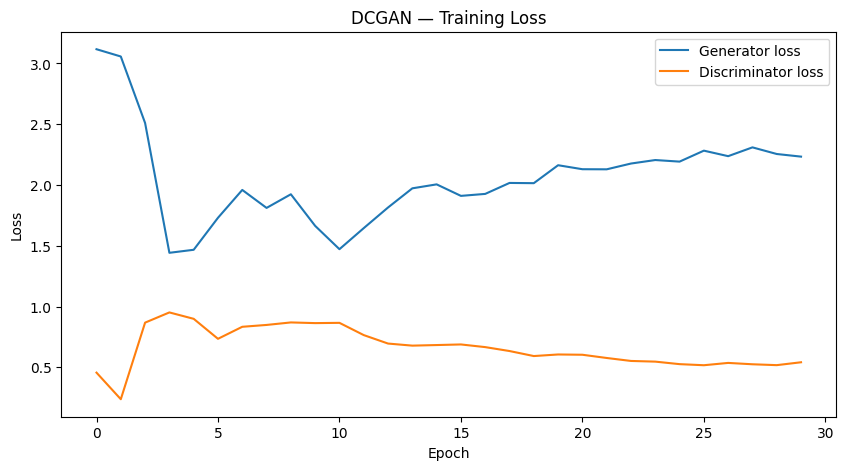

In [10]:
plt.plot(dcgan_g_losses, label="Generator loss")
plt.plot(dcgan_d_losses, label="Discriminator loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("DCGAN — Training Loss")
plt.legend(); plt.show()


## 8. Step B — WGAN (Weight Clipping)

In [11]:
wgan_gen, wgan_critic, wgan_g_losses, wgan_d_losses = train_gan(
    "WGAN", full_train_ds, epochs=EPOCHS_DIAGNOSTIC, conditional=False, weight_clip=0.01
)


[WGAN] epoch 1/30 | gen_loss=-85868.2892 | critic_loss=-34824.9035
[WGAN] epoch 3/30 | gen_loss=-197633.1424 | critic_loss=-33177.3266
[WGAN] epoch 6/30 | gen_loss=-46187.0694 | critic_loss=-3707.8194
[WGAN] epoch 9/30 | gen_loss=-14892.0874 | critic_loss=-3393.6233
[WGAN] epoch 12/30 | gen_loss=-12753.1944 | critic_loss=-2970.9080
[WGAN] epoch 15/30 | gen_loss=-23779.6528 | critic_loss=-2924.4151
[WGAN] epoch 18/30 | gen_loss=-21832.6499 | critic_loss=-2463.0550
[WGAN] epoch 21/30 | gen_loss=-2544.7920 | critic_loss=-1588.7835
[WGAN] epoch 24/30 | gen_loss=-3960.9159 | critic_loss=-783.4349
[WGAN] epoch 27/30 | gen_loss=-10301.1103 | critic_loss=-2205.9350
[WGAN] epoch 30/30 | gen_loss=-14158.3813 | critic_loss=-1858.1516


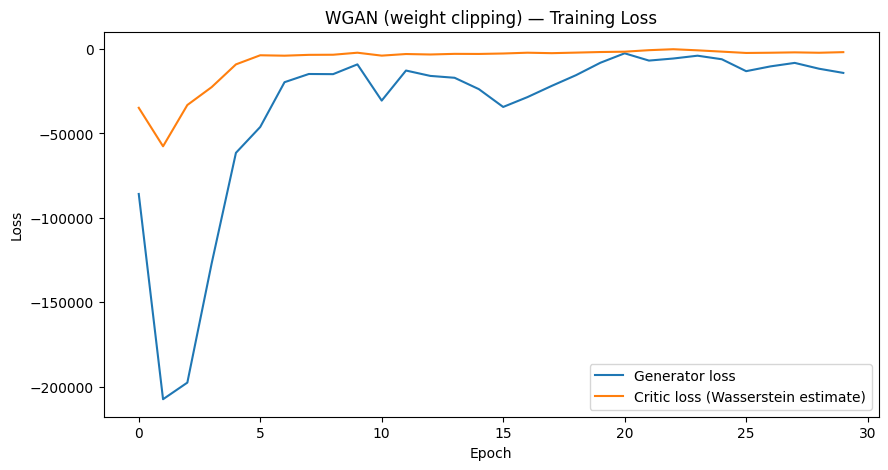

In [12]:
plt.plot(wgan_g_losses, label="Generator loss")
plt.plot(wgan_d_losses, label="Critic loss (Wasserstein estimate)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("WGAN (weight clipping) — Training Loss")
plt.legend(); plt.show()


## 9. Step C — WGAN-GP (Gradient Penalty + Layer Norm)

In [13]:
wgangp_gen, wgangp_critic, wgangp_g_losses, wgangp_d_losses = train_gan(
    "WGAN-GP", full_train_ds, epochs=EPOCHS_DIAGNOSTIC, conditional=False, use_gp=True
)


[WGAN-GP] epoch 1/30 | gen_loss=58.5892 | critic_loss=-90.9272
[WGAN-GP] epoch 3/30 | gen_loss=10.8058 | critic_loss=-23.1729
[WGAN-GP] epoch 6/30 | gen_loss=16.5666 | critic_loss=-14.7951
[WGAN-GP] epoch 9/30 | gen_loss=21.6284 | critic_loss=-12.7923
[WGAN-GP] epoch 12/30 | gen_loss=16.3252 | critic_loss=-10.7498
[WGAN-GP] epoch 15/30 | gen_loss=12.1683 | critic_loss=-8.2219
[WGAN-GP] epoch 18/30 | gen_loss=7.5573 | critic_loss=-7.7663
[WGAN-GP] epoch 21/30 | gen_loss=12.2868 | critic_loss=-7.0493
[WGAN-GP] epoch 24/30 | gen_loss=12.6197 | critic_loss=-6.6886
[WGAN-GP] epoch 27/30 | gen_loss=10.0955 | critic_loss=-5.9382
[WGAN-GP] epoch 30/30 | gen_loss=3.5567 | critic_loss=-5.3826


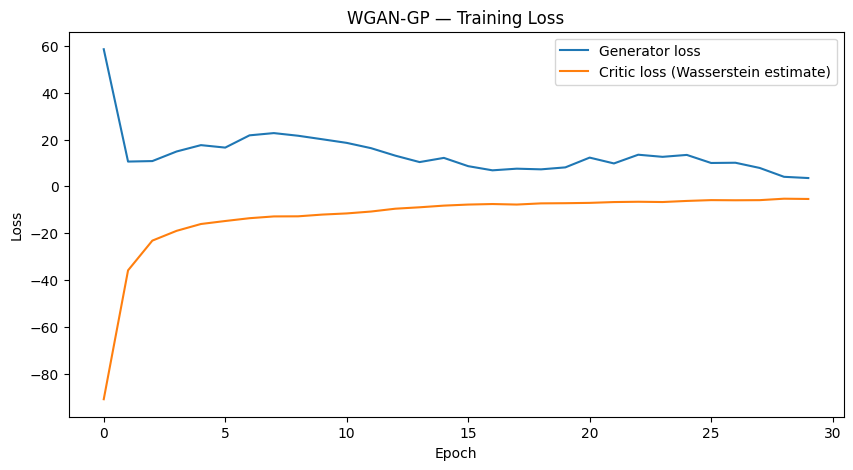

Critic loss should be smoother and trend toward 0 here compared to Steps A and B.


In [14]:
plt.plot(wgangp_g_losses, label="Generator loss")
plt.plot(wgangp_d_losses, label="Critic loss (Wasserstein estimate)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("WGAN-GP — Training Loss")
plt.legend(); plt.show()

print("Critic loss should be smoother and trend toward 0 here compared to Steps A and B.")


## 10. Step D — Conditional W-DCGAN-GP (final model)

Same WGAN-GP setup, now conditioned on the SOH bin (fresh / mid-life / aged). Train for more epochs
since this is the model whose outputs feed Phase 4 and Phase 5. Increase `EPOCHS_FINAL` once you've
confirmed Steps A–C behave as expected on your data.


In [15]:
EPOCHS_FINAL = 150  # increase once the short diagnostic runs above look sane

cwdcgan_gen, cwdcgan_critic, cwdcgan_g_losses, cwdcgan_d_losses = train_gan(
    "C-W-DCGAN-GP", full_train_ds, epochs=EPOCHS_FINAL, conditional=True, use_gp=True
)


[C-W-DCGAN-GP] epoch 1/150 | gen_loss=64.8568 | critic_loss=-102.4445
[C-W-DCGAN-GP] epoch 15/150 | gen_loss=9.5836 | critic_loss=-9.3192
[C-W-DCGAN-GP] epoch 30/150 | gen_loss=5.9725 | critic_loss=-6.8910
[C-W-DCGAN-GP] epoch 45/150 | gen_loss=-0.1513 | critic_loss=-5.4877
[C-W-DCGAN-GP] epoch 60/150 | gen_loss=-4.4037 | critic_loss=-4.4148
[C-W-DCGAN-GP] epoch 75/150 | gen_loss=-6.4649 | critic_loss=-3.7209
[C-W-DCGAN-GP] epoch 90/150 | gen_loss=-13.9369 | critic_loss=-3.2849
[C-W-DCGAN-GP] epoch 105/150 | gen_loss=-16.8961 | critic_loss=-2.6717
[C-W-DCGAN-GP] epoch 120/150 | gen_loss=-21.6563 | critic_loss=-2.3937
[C-W-DCGAN-GP] epoch 135/150 | gen_loss=-24.3928 | critic_loss=-2.3689
[C-W-DCGAN-GP] epoch 150/150 | gen_loss=-27.7493 | critic_loss=-2.0277


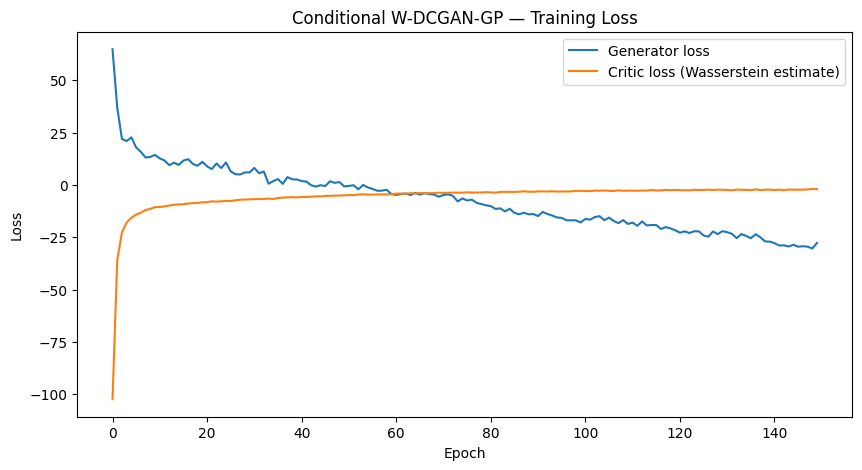

In [16]:
plt.plot(cwdcgan_g_losses, label="Generator loss")
plt.plot(cwdcgan_d_losses, label="Critic loss (Wasserstein estimate)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Conditional W-DCGAN-GP — Training Loss")
plt.legend(); plt.show()


## 11. Sanity Check: Generate Samples per SOH Bin

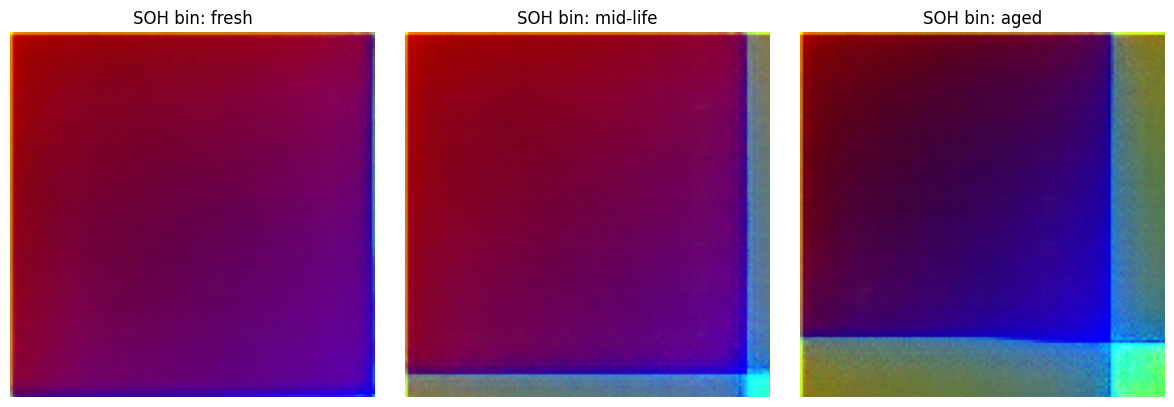

In [17]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(12, 4))
for bin_id in range(NUM_CLASSES):
    noise = tf.random.normal([1, NOISE_DIM])
    label = tf.constant([[bin_id]])
    generated = cwdcgan_gen([noise, label], training=False)[0].numpy()
    display_img = (generated + 1) / 2
    axes[bin_id].imshow(np.clip(display_img, 0, 1))
    axes[bin_id].set_title(f"SOH bin: {BIN_NAMES[bin_id]}")
    axes[bin_id].axis("off")
plt.tight_layout(); plt.show()


## 12. Save Final Model + Loss Curves for All Variants

In [18]:
cwdcgan_gen.save(os.path.join(OUTPUT_DIR, "cwdcgan_generator.keras"))
cwdcgan_critic.save(os.path.join(OUTPUT_DIR, "cwdcgan_critic.keras"))
print("Saved final conditional generator/critic.")

loss_history = pd.DataFrame({
    "epoch": list(range(1, EPOCHS_DIAGNOSTIC + 1)) ,
}).assign(
    dcgan_gen=dcgan_g_losses, dcgan_critic=dcgan_d_losses,
    wgan_gen=wgan_g_losses, wgan_critic=wgan_d_losses,
    wgangp_gen=wgangp_g_losses, wgangp_critic=wgangp_d_losses,
)
loss_history.to_csv(os.path.join(OUTPUT_DIR, "gan_diagnostic_loss_history.csv"), index=False)

final_loss_history = pd.DataFrame({
    "epoch": list(range(1, EPOCHS_FINAL + 1)),
    "gen_loss": cwdcgan_g_losses,
    "critic_loss": cwdcgan_d_losses,
})
final_loss_history.to_csv(os.path.join(OUTPUT_DIR, "cwdcgan_loss_history.csv"), index=False)

print("Phase 3 complete.")
print("Saved: cwdcgan_generator.keras, cwdcgan_critic.keras, gan_diagnostic_loss_history.csv, cwdcgan_loss_history.csv")
print("Also re-saved: nasa_gaf_labels_with_split.csv (train/test boundary for Phase 4 & 5)")


Saved final conditional generator/critic.
Phase 3 complete.
Saved: cwdcgan_generator.keras, cwdcgan_critic.keras, gan_diagnostic_loss_history.csv, cwdcgan_loss_history.csv
Also re-saved: nasa_gaf_labels_with_split.csv (train/test boundary for Phase 4 & 5)


---
### Next: Phase 4 (separate notebook)

- Generate a large batch of synthetic images per SOH bin using `cwdcgan_generator.keras`.
- Inverse-GAF them back to signals using the saved min/max from Phase 2.
- Compute SSIM, PCA/t-SNE, KL divergence between real and synthetic data.

### Then: Phase 5

- Train CNN-BiLSTM-Attention for SOH regression in three stages (real-only / TSTR / augmented),
  always evaluating on the untouched `split == "test"` cycles saved in this notebook.
